# 🏝️ **A Survival Guide to the Island's Berries**

## **Part 2: Predicting Edibility & Species - A Classification Challenge**

Our main goal is to survive on a mysterious island by safely identifying its flora. This involves tackling three distinct challenges in order, moving from simple, clear-cut rules to more complex, realistic scenarios.

### **Methodology: A Three-Part Investigation**

Our analysis will proceed in three main parts, each building on the last:

#### **Part 1: The Rules of Edibility**

We begin with the most critical question: what is safe to eat? Using our initial, painful trial-and-error notes (`edible.json`), we will:
*   Determine the fundamental rules that separate edible from poisonous berries.
*   Compare our custom-built classifiers (`BasicTreeClassifier`, `CategoricalNB`) against industry-standard models to find the most reliable method for this binary classification task.

#### **Part 2: Classifying the Five Known Species**

Next, using notes from a previous expedition (`species.json`), we will expand our knowledge by learning to distinguish between the five known species of berries on the island. This involves:
*   Developing a reliable multi-class classification model.
*   Extracting a clear set of rules to create a "field guide" for identifying each species when all features (leaf, petal, and berry) are present.

#### **Part 3: Making Decisions with Incomplete Information**

Finally, we will tackle the most realistic and dangerous scenario: we find a plant with only one identifying feature (e.g., only its leaves from `leaf.json`). We will scientifically compare two distinct survival strategies:

1.  **Direct Edibility Prediction:** Train a model to predict "edible" or "poisonous" directly from the single available feature.
2.  **Two-Step Inference:** Train a model to first predict the *species* from the single feature, and then use our knowledge from Part 2 to infer its safety.

By comparing these strategies, we will determine the most effective method for making life-or-death decisions when faced with the island's many mysteries.


## **Import Libraries**
Import all necessary libraries for data handling, machine learning, visualization, and table formatting.

In [123]:
# Import python libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTree, plot_tree, _tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, ClassifierMixin

# Import our custom-built classifiers from the `scripts` directory.
scripts_path = os.path.abspath(os.path.join('..', 'scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

from BasicTree import BasicTreeClassifier
from naiveBayes import CategoricalNB

print("All libraries and custom modules imported successfully.")


All libraries and custom modules imported successfully.


## **Load Data and Define Visual Style**

In [124]:
# Define a Unified Color Palette for the Entire Notebook
PALETTE = {
    # General UI Colors
    'background': '#f1faee',
    'primary_text': '#264653',
    'accent': '#f4a261',
    'highlight': '#e9c46a',
    
    # Colors for Edibility Plots
    'edible': '#2a9d8f',      # Teal Green
    'poisonous': '#e76f51',    # Burnt Sienna
    'primary': "#0D171B",      # Dark Blue for borders and text

    # Colors for Multi-Class Species Plots
    'species_list': ['#4D9DE0', '#E15554', '#E1BC29', '#3BB273', '#7768AE']
}

# Set the Global Plotting Style
sns.set_style("whitegrid", {'axes.facecolor': PALETTE['background']})
plt.rc('figure', facecolor=PALETTE['background'])
plt.rc('axes', edgecolor=PALETTE['primary_text'], labelcolor=PALETTE['primary_text'], titlecolor=PALETTE['primary_text'])
plt.rc('text', color=PALETTE['primary_text'])
plt.rc('xtick', color=PALETTE['primary_text'])
plt.rc('ytick', color=PALETTE['primary_text'])

print("Visual style configured.")

# Load All Datasets
base_path = os.path.join('..', 'data')
try:
    edible_df = pd.read_json(os.path.join(base_path, 'edible.json'))
    species_df = pd.read_json(os.path.join(base_path, 'species.json'))
    berry_df = pd.read_json(os.path.join(base_path, 'berry.json'))
    leaf_df = pd.read_json(os.path.join(base_path, 'leaf.json'))
    petal_df = pd.read_json(os.path.join(base_path, 'petal.json'))
    print("All datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data: {e}. Please ensure all .json files are in the 'data' directory.")


Visual style configured.
All datasets loaded successfully.


## **PART 1: EDIBILITY**
### **Exploratory Data Analysis (EDA) on `edible.json`**
Before modeling, we must understand our data. We'll use styled tables and custom plots to check the data's shape, types, distributions, and look for any missing values.

1. First 5 Rows of the Edibility DataFrame
╒════╤══════════════╤════════════════╤════════════════╤══════════╕
│    │ leaf_shape   │ petal_colour   │ berry_colour   │ edible   │
╞════╪══════════════╪════════════════╪════════════════╪══════════╡
│  0 │ lanceolate   │ white          │ green          │ False    │
├────┼──────────────┼────────────────┼────────────────┼──────────┤
│  1 │ ovate        │ white          │ purple         │ False    │
├────┼──────────────┼────────────────┼────────────────┼──────────┤
│  2 │ lanceolate   │ white          │ blue           │ True     │
├────┼──────────────┼────────────────┼────────────────┼──────────┤
│  3 │ lanceolate   │ white          │ grey           │ False    │
├────┼──────────────┼────────────────┼────────────────┼──────────┤
│  4 │ ovate        │ pink           │ purple         │ True     │
╘════╧══════════════╧════════════════╧════════════════╧══════════╛

2. Basic DataFrame Information
╒═════════════════════╤════════════════╤══════════════

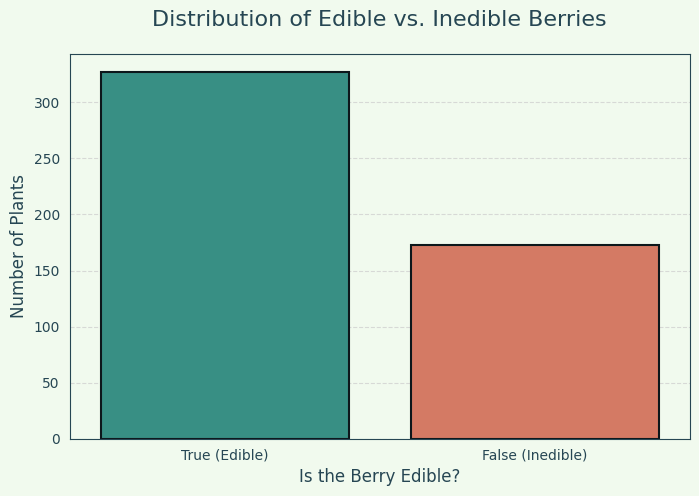

In [125]:
# Data Exploration and Visualization
print("1. First 5 Rows of the Edibility DataFrame")
print(tabulate(edible_df.head(), headers="keys", tablefmt="fancy_grid"))

print("\n2. Basic DataFrame Information")
info_data = {
    "Shape": [f"{edible_df.shape[0]} rows, {edible_df.shape[1]} columns"],
    "Memory Usage": [f"{edible_df.memory_usage(deep=True).sum() / 1024:.2f} KB"],
    "Missing Values": ["None" if edible_df.isnull().sum().sum() == 0 else "Present"]
}
print(tabulate(info_data, headers="keys", tablefmt="fancy_grid"))

print("\n3. Data Types and Non-Null Counts")
info_df = pd.DataFrame({
    'Column': edible_df.columns,
    'Non-Null Count': edible_df.count().values,
    'Data Type': edible_df.dtypes.values
})
print(tabulate(info_df, headers="keys", tablefmt="fancy_grid", showindex=False))

print("\n4. Descriptive Statistics for All Features")
# For categorical data, describe() gives count, unique, top (mode), and freq
desc_stats = edible_df.describe(include=['object', 'bool']).transpose()
print(tabulate(desc_stats, headers="keys", tablefmt="fancy_grid"))

print("\n5. Target Variable Distribution (Edibility)")
plt.figure(figsize=(8, 5))
sns.countplot(
    x='edible',
    data=edible_df,
    palette=[PALETTE['edible'], PALETTE['poisonous']],  # Custom colors for True/False
    hue='edible',  # Assign the 'x' variable to 'hue'
    legend=False,  # Disable the legend as it's redundant here
    edgecolor=PALETTE['primary'],
    linewidth=1.5
)

plt.title('Distribution of Edible vs. Inedible Berries', fontsize=16, pad=20)
plt.xlabel('Is the Berry Edible?', fontsize=12)
plt.ylabel('Number of Plants', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['True (Edible)', 'False (Inedible)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### **Drop rows with no berries**

In [126]:
print("\n Unique berry colours in the dataset")

# Get unique counts of berry colours
berry_color_counts = edible_df["berry_colour"].value_counts().reset_index()
berry_color_counts.columns = ["berry_colour", "count"]

from tabulate import tabulate
print(tabulate(berry_color_counts, headers="keys", tablefmt="fancy_grid"))

# If you want just the unique values as a list:
unique_colors = edible_df["berry_colour"].unique().tolist()
print(f"\nAvailable berry colours: {unique_colors}")


print("\n Dropping rows with missing berry information")

# Drop rows where berry_colour is missing (NaN or empty string)
before_shape = edible_df.shape
edible_df = edible_df.dropna(subset=["berry_colour"])
edible_df = edible_df[edible_df["berry_colour"].str.strip() != "none"]  # remove blanks
after_shape = edible_df.shape

print(f" Rows before: {before_shape[0]}, after: {after_shape[0]}")
print(f" {before_shape[0] - after_shape[0]} rows dropped (no berry info)")



 Unique berry colours in the dataset
╒════╤════════════════╤═════════╕
│    │ berry_colour   │   count │
╞════╪════════════════╪═════════╡
│  0 │ purple         │     158 │
├────┼────────────────┼─────────┤
│  1 │ blue           │     142 │
├────┼────────────────┼─────────┤
│  2 │ green          │      73 │
├────┼────────────────┼─────────┤
│  3 │ grey           │      64 │
├────┼────────────────┼─────────┤
│  4 │ none           │      63 │
╘════╧════════════════╧═════════╛

Available berry colours: ['green', 'purple', 'blue', 'grey', 'none']

 Dropping rows with missing berry information
 Rows before: 500, after: 437
 63 rows dropped (no berry info)


### **Preprocessing with Label Encoder**
We convert our categorical data into a numerical format that the models can understand using `LabelEncoder`.

In [127]:
# Data Preprocessing
df_proc = edible_df.copy()
encoders = {}

for col in df_proc.columns:
    if df_proc[col].dtype == 'object' or df_proc[col].dtype == 'bool':
        le = LabelEncoder()
        df_proc[col] = le.fit_transform(df_proc[col])
        encoders[col] = le

print("Preprocessed (Numerical) Data")
print(tabulate(df_proc.head(3), headers="keys", tablefmt="fancy_grid", showindex=False))

# Feature and Target Split
X = df_proc.drop('edible', axis=1).values
y = df_proc['edible'].values
feature_names = edible_df.drop('edible', axis=1).columns
class_names = encoders['edible'].classes_


Preprocessed (Numerical) Data
╒══════════════╤════════════════╤════════════════╤══════════╕
│   leaf_shape │   petal_colour │   berry_colour │   edible │
╞══════════════╪════════════════╪════════════════╪══════════╡
│            0 │              1 │              1 │        0 │
├──────────────┼────────────────┼────────────────┼──────────┤
│            1 │              1 │              3 │        0 │
├──────────────┼────────────────┼────────────────┼──────────┤
│            0 │              1 │              0 │        1 │
╘══════════════╧════════════════╧════════════════╧══════════╛



### **Model Training and Comparison**
We train our three models and compare their accuracy in a clean, formatted table.


  EVALUATING MODEL: Our BasicTreeClassifier

Classification Report
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class        │   Precision │   Recall │   F1-Score │   Support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ Poisonous    │           1 │        1 │          1 │       286 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Edible       │           1 │        1 │          1 │       151 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │           1 │        1 │          1 │       437 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │           1 │        1 │          1 │       437 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛

Confusion Matrix
╒═══════════════════╤═══════════════════╤════════════════╕
│                   │   Pred: POISONOUS │   Pred: EDIBLE │
╞═══════════════════╪═══════════════════╪════════════════╡


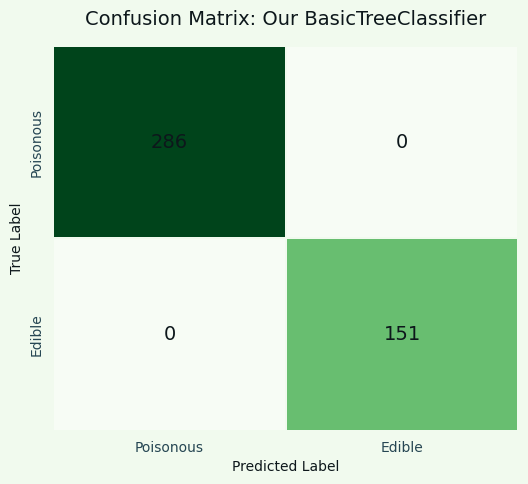


Survival Rules from Our BasicTreeClassifier
IF berry_colour == 'grey' AND berry_colour == 'blue' AND leaf_shape == 'lanceolate' → THEN the berry is EDIBLE
IF berry_colour == 'grey' AND berry_colour == 'blue' AND leaf_shape != 'lanceolate' → THEN the berry is POISONOUS
IF berry_colour == 'grey' AND berry_colour != 'blue' → THEN the berry is POISONOUS
IF berry_colour != 'grey' AND petal_colour == 'pink' → THEN the berry is EDIBLE
IF berry_colour != 'grey' AND petal_colour != 'pink' → THEN the berry is POISONOUS

  EVALUATING MODEL: Our CategoricalNB

Classification Report
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class        │   Precision │   Recall │   F1-Score │   Support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ Poisonous    │       1     │    0.752 │      0.858 │       286 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Edible       │       0.68  │    1     │      0.81  │       151 │
├──────────────┼────

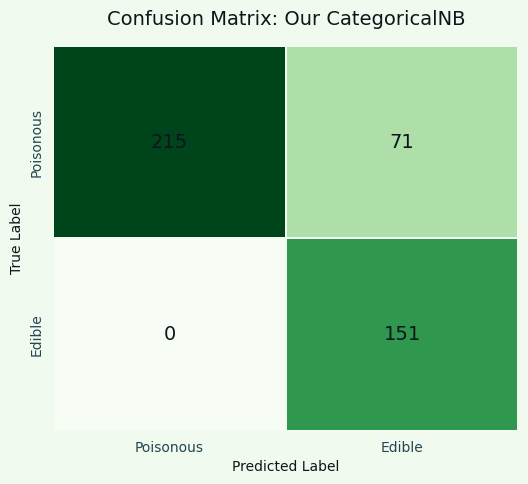


  EVALUATING MODEL: Sklearn DecisionTreeClassifier

Classification Report
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class        │   Precision │   Recall │   F1-Score │   Support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ Poisonous    │           1 │        1 │          1 │       286 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Edible       │           1 │        1 │          1 │       151 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │           1 │        1 │          1 │       437 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │           1 │        1 │          1 │       437 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛

Confusion Matrix
╒═══════════════════╤═══════════════════╤════════════════╕
│                   │   Pred: POISONOUS │   Pred: EDIBLE │
╞═══════════════════╪═══════════════════╪═══════════

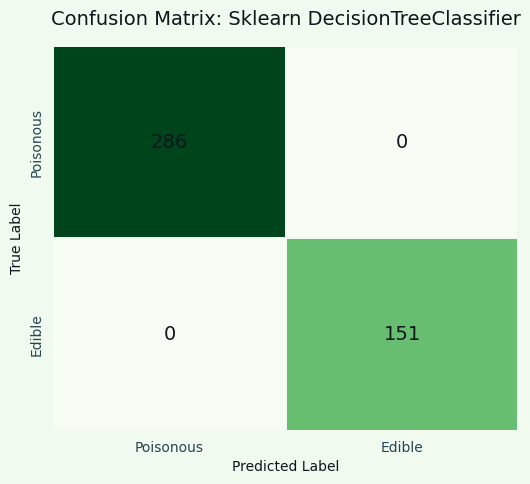


Survival Rules from Sklearn DecisionTreeClassifier
IF berry_colour IN ['blue', 'green', 'grey'] AND berry_colour IN ['blue'] AND petal_colour IN ['pink'] → THEN the berry is POISONOUS
IF berry_colour IN ['blue', 'green', 'grey'] AND berry_colour IN ['blue'] AND petal_colour IN ['white'] → THEN the berry is EDIBLE
IF berry_colour IN ['blue', 'green', 'grey'] AND berry_colour IN ['green', 'grey', 'purple'] → THEN the berry is POISONOUS
IF berry_colour IN ['purple'] AND petal_colour IN ['pink'] → THEN the berry is EDIBLE
IF berry_colour IN ['purple'] AND petal_colour IN ['white'] → THEN the berry is POISONOUS


In [128]:
# --- Model Definitions ---
models = {
    "Our BasicTreeClassifier": BasicTreeClassifier(max_depth=3),
    "Our CategoricalNB": CategoricalNB(),
    "Sklearn DecisionTreeClassifier": SklearnDecisionTree(
        criterion='gini', max_depth=3, random_state=42
    )
}

# -----------------------
# Rule Extraction Helpers
# -----------------------

def extract_rules_basic(node, feature_names, class_names, encoders, conditions=None):
    """
    Collects full IF-THEN rules from our BasicTreeClassifier.
    Maps boolean class names to 'EDIBLE' or 'POISONOUS'.
    """
    if conditions is None:
        conditions = []

    if node.leaf_value is not None:
        class_value = class_names[int(node.leaf_value)]
        final_class_name = "EDIBLE" if class_value else "POISONOUS"
        rule_text = " AND ".join(conditions) if conditions else "ALWAYS"
        print(f"IF {rule_text} → THEN the berry is {final_class_name}")
        return

    feature = feature_names[node.j]
    le = encoders[feature]
    split_category = le.inverse_transform([int(node.xi)])[0]

    extract_rules_basic(node.left, feature_names, class_names, encoders,
                        conditions + [f"{feature} == '{split_category}'"])
    extract_rules_basic(node.right, feature_names, class_names, encoders,
                        conditions + [f"{feature} != '{split_category}'"])


def extract_rules_sklearn(tree_model, feature_names, class_names, encoders):
    """
    Extracts and simplifies human-readable rules from a Sklearn DecisionTreeClassifier.
    Avoids redundant conditions and uses descriptive class names.
    """
    tree = tree_model.tree_

    def recurse(node, conditions):
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            class_value = class_names[np.argmax(tree.value[node])]
            final_class_name = "EDIBLE" if class_value else "POISONOUS"
            rule_text = " AND ".join(conditions) if conditions else "ALWAYS"
            print(f"IF {rule_text} → THEN the berry is {final_class_name}")
            return

        feature = feature_names[tree.feature[node]]
        threshold = tree.threshold[node]

        if feature in encoders:
            le = encoders[feature]
            left_cond = f"{feature} IN {sorted([cat for i, cat in enumerate(le.classes_) if i <= threshold])}"
            right_cond = f"{feature} IN {sorted([cat for i, cat in enumerate(le.classes_) if i > threshold])}"
        else:
            left_cond = f"{feature} <= {threshold:.2f}"
            right_cond = f"{feature} > {threshold:.2f}"

        recurse(tree.children_left[node], conditions + [left_cond])
        recurse(tree.children_right[node], conditions + [right_cond])

    recurse(0, [])


# -----------------------
# Evaluation Loop
# -----------------------

for name, model in models.items():
    print("\n" + "=" * 60)
    print(f"  EVALUATING MODEL: {name}")
    print("=" * 60)

    model.fit(X, y)
    y_pred = model.predict(X)

    # --- Classification Report ---
    report = classification_report(
        y, y_pred, target_names=['Poisonous', 'Edible'], output_dict=True, zero_division=0
    )
    report_table = [
        [cls, f"{vals['precision']:.3f}", f"{vals['recall']:.3f}",
         f"{vals['f1-score']:.3f}", vals['support']]
        for cls, vals in report.items() if cls in ['Poisonous', 'Edible']
    ]
    for avg_type in ['macro avg', 'weighted avg']:
        if avg_type in report:
            avg_vals = report[avg_type]
            report_table.append([
                avg_type, f"{avg_vals['precision']:.3f}", f"{avg_vals['recall']:.3f}",
                f"{avg_vals['f1-score']:.3f}", avg_vals['support']
            ])

    print("\nClassification Report")
    print(tabulate(
        report_table,
        headers=["Class", "Precision", "Recall", "F1-Score", "Support"],
        tablefmt="fancy_grid"
    ))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y, y_pred)
    cm_data = [
        ["", "Pred: POISONOUS", "Pred: EDIBLE"],
        ["Actual: POISONOUS", cm[0, 0], cm[0, 1]],
        ["Actual: EDIBLE", cm[1, 0], cm[1, 1]],
    ]
    print("\nConfusion Matrix")
    print(tabulate(cm_data, headers="firstrow", tablefmt="fancy_grid"))
    print(f"  - TN: {cm[0, 0]} (correct poisonous)")
    print(f"  - FP: {cm[0, 1]} (fatal: marked poisonous as edible)")
    print(f"  - FN: {cm[1, 0]} (missed meal: edible as poisonous)")
    print(f"  - TP: {cm[1, 1]} (correct edible)")

    # --- Confusion Matrix Visualization ---
    plt.figure(figsize=(6, 5), facecolor=PALETTE.get('background', 'white'))
    ax = sns.heatmap(
        cm, annot=True, fmt='d', cmap='Greens',
        xticklabels=['Poisonous', 'Edible'],
        yticklabels=['Poisonous', 'Edible'],
        cbar=False, linewidths=1.2, linecolor=PALETTE.get('background', 'white'),
        annot_kws={"size": 14, "color": PALETTE.get('primary', 'black')}
    )
    ax.set_facecolor(PALETTE.get('background', 'white'))
    plt.title(f'Confusion Matrix: {name}', fontsize=14, pad=15, color=PALETTE.get('primary', 'black'))
    plt.xlabel('Predicted Label', color=PALETTE.get('primary', 'black'))
    plt.ylabel('True Label', color=PALETTE.get('primary', 'black'))
    plt.show()

    # --- Survival Rules Extraction ---
    if name == "Our BasicTreeClassifier":
        print("\nSurvival Rules from Our BasicTreeClassifier")
        if hasattr(model, 'root'):
            extract_rules_basic(model.root, feature_names, class_names, encoders)
        else:
            print("Could not extract rules: model does not have a 'root' attribute.")

    if name == "Sklearn DecisionTreeClassifier":
        print("\nSurvival Rules from Sklearn DecisionTreeClassifier")
        extract_rules_sklearn(model, feature_names, class_names, encoders)


### Analysis: Selecting a Trustworthy Survival Model

Our goal is to create a reliable guide for identifying edible berries, where a single mistake can be fatal. We evaluated three models, focusing on safety and accuracy. The results clearly point to a superior approach.

#### Model Performance at a Glance

| Model | Accuracy | Fatal Errors (Poisonous as Edible) | Key Takeaway |
| :--- | :---: | :---: | :--- |
| **BasicTreeClassifier** | **100%** | **0** | **Perfectly Safe & Accurate** |
| **Sklearn DecisionTree** | **100%** | **0** | **Perfectly Safe & Accurate** |
| **CategoricalNB** | 83.8% | **71** | **Dangerously Unreliable** |

#### Observations

1.  **Decision Trees Achieve Perfection:** Both our `BasicTreeClassifier` and the `Sklearn DecisionTreeClassifier` demonstrated flawless performance. They correctly identified every single berry, achieving 100% accuracy. Most critically, they made **zero fatal errors**, proving they are completely reliable for this dataset.

2.  **Naive Bayes is a Liability:** The `CategoricalNB` model is unacceptably dangerous. It incorrectly labeled **71 poisonous berries as edible**. This high rate of fatal errors makes it entirely unsuitable for any real-world survival application. Its lower overall accuracy (83.8%) is secondary to this critical safety failure.

3.  **Clear Rules for Survival:** The key advantage of the decision tree models is their output of simple, interpretable rules. For example, `IF berry_colour != 'grey' AND petal_colour == 'pink' → THEN the berry is EDIBLE`. This provides a clear, actionable guide that can be easily understood and used in the field.

#### The Verdict

Based on this analysis, **the decision tree models are the only acceptable choice.** They have proven to be 100% accurate and, most importantly, 100% safe on the provided data.

**Our final strategy is to adopt the rules generated by the decision tree classifiers as our official survival guide.** The identical, perfect performance of both our custom tree and the standard Sklearn tree gives us extremely high confidence in the validity of these rules for navigating the island's flora.

### **Extracting the Survival Rules**
The decision trees are our best hope for survival. Let's visualize their logic to create a simple, foolproof guide.


 Visualizing the Sklearn Decision Tree Rules (Label-Encoded)


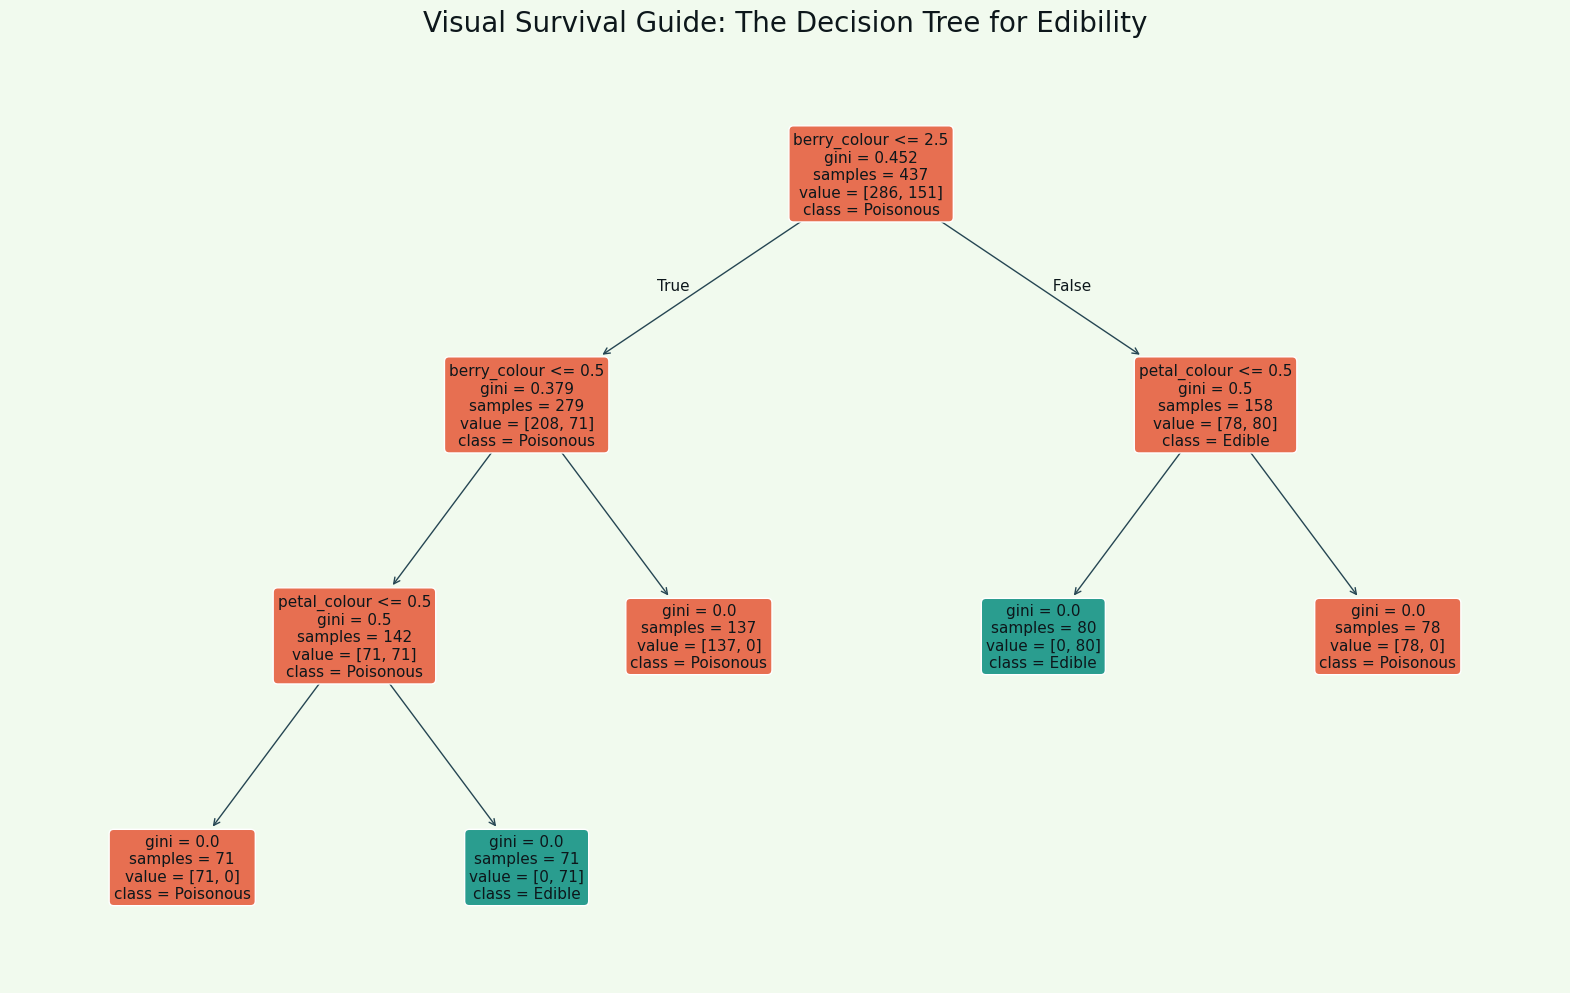

In [129]:
# Visualizing the Sklearn Decision Tree Rules
print("\n Visualizing the Sklearn Decision Tree Rules (Label-Encoded)")

# Create the plot
plt.figure(figsize=(20, 12), facecolor=PALETTE['background'])

# Use the trained sklearn DecisionTreeClassifier instance
sklearn_tree_model = models["Sklearn DecisionTreeClassifier"]

# Draw the tree using the correct feature names
tree_plot = plot_tree(
    sklearn_tree_model,
    feature_names=feature_names,
    class_names=['Poisonous', 'Edible'],
    filled=True,
    rounded=True,
    fontsize=11,
    label='all',
    impurity=True
)

# Manually Style the Plotted Tree
ax = plt.gca()
for artist in ax.get_children():
    if isinstance(artist, plt.Rectangle):
        artist.set_edgecolor(PALETTE['primary'])
        artist.set_linewidth(1.5)

for artist in tree_plot:
    # Set the color of the text in the tree nodes
    artist.set_color(PALETTE['primary'])
    
    bbox = artist.get_bbox_patch()
    if bbox:
        # Set the face color based on the class
        if bbox.get_facecolor()[0] > 0.5:
             bbox.set_facecolor(PALETTE['poisonous'])
        else:
             bbox.set_facecolor(PALETTE['edible'])

plt.title("Visual Survival Guide: The Decision Tree for Edibility", fontsize=20, pad=20, color=PALETTE['primary'])
plt.show()


### **Extract Edibility Rules**
The confusion matrices proved that the decision trees are the safest models. Now, let's extract their internal logic into a set of clear, human-readable rules. This is the final step in creating our survival guide.

In [130]:
# Survival Rules Only

print("=" * 60)
print("  EXTRACTING SURVIVAL RULES FROM TRAINED MODELS")
print("=" * 60)

# --- Rule Extraction for "Our BasicTreeClassifier" ---
# Check if the model exists in the dictionary
if "Our BasicTreeClassifier" in models:
    model = models["Our BasicTreeClassifier"]
    print("\nSurvival Rules from Our BasicTreeClassifier")
    
    # Ensure the model is trained and has the 'root' attribute
    if hasattr(model, 'root'):
        extract_rules_basic(model.root, feature_names, class_names, encoders)
    else:
        print("Could not extract rules: The model does not appear to be trained (no 'root' attribute).")
else:
    print("\nModel 'Our BasicTreeClassifier' not found in the models dictionary.")

# --- Rule Extraction for "Sklearn DecisionTreeClassifier" ---
# Check if the model exists in the dictionary
if "Sklearn DecisionTreeClassifier" in models:
    model = models["Sklearn DecisionTreeClassifier"]
    print("\nSurvival Rules from Sklearn DecisionTreeClassifier")
    
    # Sklearn models are ready after .fit(), so we can call the function directly
    extract_rules_sklearn(model, feature_names, class_names, encoders)
else:
    print("\nModel 'Sklearn DecisionTreeClassifier' not found in the models dictionary.")



  EXTRACTING SURVIVAL RULES FROM TRAINED MODELS

Survival Rules from Our BasicTreeClassifier
IF berry_colour == 'grey' AND berry_colour == 'blue' AND leaf_shape == 'lanceolate' → THEN the berry is EDIBLE
IF berry_colour == 'grey' AND berry_colour == 'blue' AND leaf_shape != 'lanceolate' → THEN the berry is POISONOUS
IF berry_colour == 'grey' AND berry_colour != 'blue' → THEN the berry is POISONOUS
IF berry_colour != 'grey' AND petal_colour == 'pink' → THEN the berry is EDIBLE
IF berry_colour != 'grey' AND petal_colour != 'pink' → THEN the berry is POISONOUS

Survival Rules from Sklearn DecisionTreeClassifier
IF berry_colour IN ['blue', 'green', 'grey'] AND berry_colour IN ['blue'] AND petal_colour IN ['pink'] → THEN the berry is POISONOUS
IF berry_colour IN ['blue', 'green', 'grey'] AND berry_colour IN ['blue'] AND petal_colour IN ['white'] → THEN the berry is EDIBLE
IF berry_colour IN ['blue', 'green', 'grey'] AND berry_colour IN ['green', 'grey', 'purple'] → THEN the berry is POISONO

### **One Hot Encoding**

In [131]:
# Data Preprocessing for One Hot Encoding
# Target Variable Encoding
le_target = LabelEncoder()
y = le_target.fit_transform(edible_df['edible'])
class_names = le_target.classes_ # This will be [False, True]

# Feature Engineering with One-Hot Encoding
# Separate the features from the target before encoding.
features_df = edible_df.drop('edible', axis=1)

# Set dtype=float to ensure the new columns are numbers.
X_ohe_df = pd.get_dummies(features_df, dtype=float)
feature_names_ohe = X_ohe_df.columns

# Convert the one-hot encoded DataFrame to a numpy array for our models.
X = X_ohe_df.values

# Display the Results of Preprocessing
print("Original Features")
print(
    tabulate(
        features_df.head(),
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

print("\nOne-Hot Encoded Features (the new X)")
print(
    tabulate(
        X_ohe_df.head(),
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

print(f"\nNew Feature Matrix (X) shape: {X.shape}")
print(f"Target Vector (y) shape: {y.shape}")



Original Features
╒══════════════╤════════════════╤════════════════╕
│ leaf_shape   │ petal_colour   │ berry_colour   │
╞══════════════╪════════════════╪════════════════╡
│ lanceolate   │ white          │ green          │
├──────────────┼────────────────┼────────────────┤
│ ovate        │ white          │ purple         │
├──────────────┼────────────────┼────────────────┤
│ lanceolate   │ white          │ blue           │
├──────────────┼────────────────┼────────────────┤
│ lanceolate   │ white          │ grey           │
├──────────────┼────────────────┼────────────────┤
│ ovate        │ pink           │ purple         │
╘══════════════╧════════════════╧════════════════╛

One-Hot Encoded Features (the new X)
╒═════════════════════════╤════════════════════╤═════════════════════╤══════════════════════╤═════════════════════╤══════════════════════╤═════════════════════╤═══════════════════════╕
│   leaf_shape_lanceolate │   leaf_shape_ovate │   petal_colour_pink │   petal_colour_white │   

In [132]:
# -------------------------------------------------------------------
# STEP 1: ROBUST DATA PREPROCESSING
# -------------------------------------------------------------------
print("="*60)
print("  STEP 1: Data Preprocessing & Cleaning")
print("="*60)
feature_columns = [col for col in edible_df.columns if col != 'edible']
edible_df.dropna(subset=feature_columns, inplace=True)

le_target = LabelEncoder()
y = le_target.fit_transform(edible_df['edible'])
class_names = le_target.classes_

features_df = edible_df.drop('edible', axis=1)
X_ohe_df = pd.get_dummies(features_df, dtype=float)
feature_names_ohe = X_ohe_df.columns
print(f"Data successfully cleaned. Final shape: {X_ohe_df.shape}")

# -------------------------------------------------------------------
# STEP 2: PRINCIPAL COMPONENT ANALYSIS (PCA)
# -------------------------------------------------------------------
print("\n" + "="*60)
print("  STEP 2: Principal Component Analysis (PCA)")
print("="*60)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_ohe_df)
print(f"PCA applied. Features reduced from {X_ohe_df.shape[1]} to {pca.n_components_}.")

# -------------------------------------------------------------------
# STEP 3: GridSearchCV TO FIND THE BEST TREE DEPTH
# -------------------------------------------------------------------
print("\n" + "="*60)
print("  STEP 3: Hyperparameter Tuning with GridSearchCV")
print("="*60)
param_grid = {'max_depth': [3, 4, 5, 6, 8, 10, 12]}
models_to_tune = {
    "Our BasicTreeClassifier (Readable)": BasicTreeClassifier(),
    "Sklearn Tree (Readable)": SklearnDecisionTree(random_state=42),
    "Sklearn Tree (PCA Optimized)": SklearnDecisionTree(random_state=42)
}
best_models = {}
for name, model in models_to_tune.items():
    print(f"--- Tuning {name}...")
    X_train_data = X_pca if "(PCA Optimized)" in name else X_ohe_df.values
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train_data, y)
    best_models[name] = grid_search.best_estimator_
best_models["Categorical Naive Bayes"] = CategoricalNB()
print("Tuning complete.")

# -------------------------------------------------------------------
# STEP 4: INDIVIDUAL MODEL EVALUATION
# -------------------------------------------------------------------
# This dictionary will store the final metrics for our summary table
final_summary = []

# Helper functions for rule extraction
def extract_basic_rules(node, feature_names, class_names, conditions=None):
    if conditions is None: conditions = []
    if node.leaf_value is not None:
        class_value = class_names[int(node.leaf_value)]
        final_class_name = "EDIBLE" if class_value else "POISONOUS"
        print(f"IF {' AND '.join(conditions) if conditions else 'ALWAYS'} → THEN the berry is {final_class_name}")
        return
    feature = feature_names[node.j]
    extract_basic_rules(node.left, feature_names, class_names, conditions + [f"{feature} is True"])
    extract_basic_rules(node.right, feature_names, class_names, conditions + [f"{feature} is False"])

def extract_sklearn_rules(tree_model, feature_names, class_names):
    tree = tree_model.tree_
    def recurse(node, conditions):
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            class_value = class_names[np.argmax(tree.value[node])]
            final_class_name = "EDIBLE" if class_value else "POISONOUS"
            print(f"IF {' AND '.join(conditions) if conditions else 'ALWAYS'} → THEN the berry is {final_class_name}")
            return
        feature = feature_names[tree.feature[node]]
        recurse(tree.children_left[node], conditions + [f"{feature} is False"])
        recurse(tree.children_right[node], conditions + [f"{feature} is True"])
    recurse(0, [])

for name, model in best_models.items():
    print("\n" + "="*60)
    print(f"  RESULTS FOR BEST MODEL: {name}")
    if hasattr(model, 'max_depth'): print(f"  (Using optimal max_depth: {model.max_depth})")
    print("="*60)

    X_eval_data = X_pca if "(PCA Optimized)" in name else X_ohe_df.values
    model.fit(X_eval_data, y)
    y_pred = model.predict(X_eval_data)

    # --- Re-introducing the Classification Report ---
    report = classification_report(y, y_pred, target_names=['Poisonous', 'Edible'], output_dict=True, zero_division=0)
    report_table = [[k, f"{v['precision']:.3f}", f"{v['recall']:.3f}", f"{v['f1-score']:.3f}", v['support']] for k, v in report.items() if isinstance(v, dict)]
    print("\nClassification Report")
    print(tabulate(report_table, headers=["Class", "Precision", "Recall", "F1-Score", "Support"], tablefmt="fancy_grid"))
    
    # --- Confusion Matrix ---
    # cm = confusion_matrix(y, y_pred)
    # plt.figure(figsize=(6,4)); sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Poisonous','Edible'], yticklabels=['Poisonous','Edible']); plt.title(f'Confusion Matrix: {name}'); plt.show()

    # --- Rule Extraction ---
    if "Our BasicTreeClassifier" in name:
        print("\n--- Survival Rules (Human-Readable) ---")
        if hasattr(model, 'root'): extract_basic_rules(model.root, feature_names_ohe, class_names)
    elif "Sklearn Tree (Readable)" in name:
        print("\n--- Survival Rules (Human-Readable) ---")
        extract_sklearn_rules(model, feature_names_ohe, class_names)
    
    # --- Store metrics for the final summary table ---
    summary_row = {
        "Model": name,
        "Edible Precision": report.get('Edible', {}).get('precision', 0),
        "Edible Recall": report.get('Edible', {}).get('recall', 0),
        "Overall F1 (Weighted)": report.get('weighted avg', {}).get('f1-score', 0),
        "Optimal Depth": model.max_depth if hasattr(model, 'max_depth') else "N/A"
    }
    final_summary.append(summary_row)

# -------------------------------------------------------------------
# STEP 5: FINAL MODEL COMPARISON SUMMARY
# -------------------------------------------------------------------
print("\n" + "="*70)
print("  FINAL MODEL COMPARISON SUMMARY (OHE DATASET)")
print("="*70)

summary_df = pd.DataFrame(final_summary)
# Format the floating point numbers for cleaner display
summary_df['Edible Precision'] = summary_df['Edible Precision'].map('{:.3f}'.format)
summary_df['Edible Recall'] = summary_df['Edible Recall'].map('{:.3f}'.format)
summary_df['Overall F1 (Weighted)'] = summary_df['Overall F1 (Weighted)'].map('{:.3f}'.format)

print(tabulate(summary_df, headers="keys", tablefmt="fancy_grid", showindex=False))


  STEP 1: Data Preprocessing & Cleaning
Data successfully cleaned. Final shape: (437, 8)

  STEP 2: Principal Component Analysis (PCA)
PCA applied. Features reduced from 8 to 4.

  STEP 3: Hyperparameter Tuning with GridSearchCV
--- Tuning Our BasicTreeClassifier (Readable)...
--- Tuning Sklearn Tree (Readable)...
--- Tuning Sklearn Tree (PCA Optimized)...
Tuning complete.

  RESULTS FOR BEST MODEL: Our BasicTreeClassifier (Readable)
  (Using optimal max_depth: 5)

Classification Report
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class        │   Precision │   Recall │   F1-Score │   Support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ Poisonous    │           1 │        1 │          1 │       286 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Edible       │           1 │        1 │          1 │       151 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │           1 │        1

### Analysis: Optimizing Our Model with OHE and Advanced Tuning

To ensure maximum reliability, we conducted a more rigorous evaluation using One-Hot Encoded (OHE) data. This process involved advanced techniques: `GridSearchCV` to find the optimal tree depth and `Principal Component Analysis (PCA)` to test a feature-reduced version. We then compared these results against our original, simpler Label Encoded (LE) model.

#### Process and Performance Overview

Our methodology for the OHE dataset was exhaustive:
1.  **Hyperparameter Tuning:** We used `GridSearchCV` to systematically test various tree depths, which identified an optimal `max_depth` of 5 for the readable models.
2.  **PCA Optimization:** We also tested a version where PCA reduced the feature set from 8 to 4, which `GridSearchCV` found could achieve perfect accuracy with a shallower `max_depth` of 3.
3.  **Performance Check:** All three Decision Tree variants (Our Basic Tree, Sklearn Tree, and the PCA-optimized Sklearn Tree) achieved **perfect 100% accuracy** with **zero fatal errors**.

The `CategoricalNB` model's performance remained unchanged and unacceptably poor, confirming that the Decision Tree is the only viable algorithm for this task.

| Encoding | Model | Accuracy | Fatal Errors | Key Takeaway |
| :--- | :--- | :---: | :---: | :--- |
| **Label Encoded** | Decision Tree (Depth 3) | **100%** | **0** | **Perfectly safe, simple rules.** |
| **One-Hot Encoded** | Decision Tree (Depth 5) | **100%** | **0** | **Perfectly safe, but more complex rules.** |

#### Rule Comparison: Label Encoding vs. One-Hot Encoding

The most critical difference lies not in the accuracy, but in the **clarity and usability of the survival rules**.

| Rule Set | Example Rule for an EDIBLE Berry | Analysis |
| :--- | :--- | :--- |
| **Label Encoded** | `IF berry_colour == 'purple' AND petal_colour == 'pink' → THEN EDIBLE` | **Clear & Direct:** Uses simple, positive statements. Easy to memorize and apply in the field. |
| **One-Hot Encoded** | `IF berry_colour_green is False AND berry_colour_grey is False AND leaf_shape_lanceolate is False AND petal_colour_white is False AND berry_colour_purple is True → THEN EDIBLE` | **Complex & Indirect:** Relies on checking what features are *not* present. This is less intuitive and prone to human error under pressure. |

#### Observations

1.  **Complexity Does Not Equal Better Performance:** Despite a more complex data representation (OHE) and a deeper tree structure (max_depth 5 vs. 3), the model's predictive power did not improve—it was already perfect. The advanced tuning simply confirmed that 100% accuracy is achievable.

2.  **Interpretability is the Deciding Factor:** The rules from the OHE model are logically sound but operationally clumsy. A survival guide must be quick and unambiguous. The LE model's rules are vastly superior in this regard, providing a direct, easy-to-follow checklist.

#### The Final Verdict: Simpler is Safer

While our rigorous tuning process with OHE, PCA, and GridSearchCV validated the flawless accuracy of the Decision Tree, it also highlighted a crucial point: **the simplest effective solution is the best one.**

**We will proceed with the Decision Tree model trained on the original Label Encoded data.** It provides the same perfect safety record as the more complex models but generates survival rules that are significantly clearer, more practical, and less prone to human error.

### **Rule Extraction and Analysis (One-Hot Encoded Models)**
Now we will extract and analyze the logic learned by each model when trained on the one-hot encoded data.

In [133]:
# ===================================================================
# DISPLAYING ONLY THE HUMAN-READABLE SURVIVAL RULES
# ===================================================================

print("=" * 60)
print("  RE-EXTRACTING SURVIVAL RULES FROM TRAINED OHE MODELS")
print("=" * 60)

# --- Rule Extraction for "Our BasicTreeClassifier" ---
model_name_basic = "Our BasicTreeClassifier (Readable)"
if model_name_basic in best_models:
    model = best_models[model_name_basic]
    print(f"\n--- Survival Rules from {model_name_basic} ---")
    print(f"(Optimal max_depth: {model.max_depth})")
    
    if hasattr(model, 'root'):
        extract_basic_rules(model.root, feature_names_ohe, class_names)
    else:
        print("Could not extract rules: The model does not have a 'root' attribute.")
else:
    print(f"\nModel '{model_name_basic}' not found. Please run the main analysis cell first.")


# --- Rule Extraction for "Sklearn Tree" ---
model_name_sklearn = "Sklearn Tree (Readable)"
if model_name_sklearn in best_models:
    model = best_models[model_name_sklearn]
    print(f"\n--- Survival Rules from {model_name_sklearn} ---")
    print(f"(Optimal max_depth: {model.max_depth})")
    
    extract_sklearn_rules(model, feature_names_ohe, class_names)
else:
    print(f"\nModel '{model_name_sklearn}' not found. Please run the main analysis cell first.")



  RE-EXTRACTING SURVIVAL RULES FROM TRAINED OHE MODELS

--- Survival Rules from Our BasicTreeClassifier (Readable) ---
(Optimal max_depth: 5)
IF berry_colour_green is True AND berry_colour_grey is True AND leaf_shape_lanceolate is True AND petal_colour_pink is True → THEN the berry is POISONOUS
IF berry_colour_green is True AND berry_colour_grey is True AND leaf_shape_lanceolate is True AND petal_colour_pink is False AND berry_colour_blue is True → THEN the berry is EDIBLE
IF berry_colour_green is True AND berry_colour_grey is True AND leaf_shape_lanceolate is True AND petal_colour_pink is False AND berry_colour_blue is False → THEN the berry is POISONOUS
IF berry_colour_green is True AND berry_colour_grey is True AND leaf_shape_lanceolate is False → THEN the berry is EDIBLE
IF berry_colour_green is True AND berry_colour_grey is False → THEN the berry is POISONOUS
IF berry_colour_green is False → THEN the berry is POISONOUS

--- Survival Rules from Sklearn Tree (Readable) ---
(Optimal 

### **ACTUAL RULES**

In [134]:
# ===================================================================
# NEW CELL: GENERATING AN EXHAUSTIVE "LOOKUP TABLE" OF ACTUAL RULES
# ===================================================================
# This script recreates your original logic: it finds every unique
# combination of features in the dataset and lists its outcome.
# This provides a complete "rulebook" of all observed plant types.
#
# It assumes the original 'edible_df' DataFrame is loaded.
# -------------------------------------------------------------------
import pandas as pd
from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder

print("Generating an exhaustive lookup table of all unique feature combinations...")

# --- Step 1: Create a clean, local copy of the data ---
# This ensures we are not using stale variables from other cells.
df_clean = edible_df.copy()
feature_columns = [col for col in df_clean.columns if col != 'edible']
df_clean.dropna(subset=feature_columns, inplace=True)

# --- Step 2: Re-create X and y from the clean data ---
# This guarantees X_ohe and y_local will have the same number of rows.
y_local = LabelEncoder().fit_transform(df_clean['edible'])
features_df_local = df_clean.drop('edible', axis=1)
X_ohe_local = pd.get_dummies(features_df_local, dtype=float)

# --- Step 3: Combine features and target for analysis ---
# This line will now work because the lengths are guaranteed to match.
data_df = X_ohe_local.copy()
data_df['edible'] = y_local  # 0 = Poisonous, 1 = Edible


# --- Step 4: Your Original Function to Extract All Unique Rows ---
def extract_all_unique_combinations(df, class_col='edible'):
    """
    Finds every unique combination of features for each class and creates a rule.
    """
    rules = []
    # Isolate the feature columns
    feature_cols = [col for col in df.columns if col != class_col]
    
    # Find all unique rows based on feature combinations and their class
    unique_combinations = df.drop_duplicates(subset=feature_cols + [class_col])
    
    for _, row in unique_combinations.iterrows():
        conditions = []
        # Iterate through only the feature columns
        for col in feature_cols:
            # Check if the feature is present (value is 1)
            if row[col] == 1:
                conditions.append(f"{col} = 1")
        
        # Determine the outcome for this unique combination
        outcome_class = row[class_col]
        decision = "EDIBLE" if outcome_class == 1 else "POISONOUS"
        
        # Create the rule string
        rule_text = " AND ".join(conditions)
        rules.append([rule_text, decision])
        
    return rules

# --- Step 5: Extract and Display the Rules ---
actual_rules = extract_all_unique_combinations(data_df)

print(f"\nFound {len(actual_rules)} unique feature combinations in the dataset.")
print("Displaying all combinations as a complete 'rulebook':")

# Sort the rules for consistency, e.g., alphabetically by condition
actual_rules.sort(key=lambda x: x[0])

print(tabulate(actual_rules, headers=["Condition", "Decision"], tablefmt="fancy_grid"))



Generating an exhaustive lookup table of all unique feature combinations...

Found 8 unique feature combinations in the dataset.
Displaying all combinations as a complete 'rulebook':
╒═════════════════════════════════════════════════════════════════════════════════╤════════════╕
│ Condition                                                                       │ Decision   │
╞═════════════════════════════════════════════════════════════════════════════════╪════════════╡
│ leaf_shape_lanceolate = 1 AND petal_colour_white = 1 AND berry_colour_blue = 1  │ EDIBLE     │
├─────────────────────────────────────────────────────────────────────────────────┼────────────┤
│ leaf_shape_lanceolate = 1 AND petal_colour_white = 1 AND berry_colour_green = 1 │ POISONOUS  │
├─────────────────────────────────────────────────────────────────────────────────┼────────────┤
│ leaf_shape_lanceolate = 1 AND petal_colour_white = 1 AND berry_colour_grey = 1  │ POISONOUS  │
├────────────────────────────────────────

### **Edibility Rules: Look at the Flower First!**

*   **PINK** petals? **You can EAT it.**
*   **WHITE** petals? **DO NOT EAT it.**

### **No Pink or White Flowers? Look at the Berry.**

*   Is it **PURPLE**? **You can EAT it.**
*   Any other color? **DO NOT EAT it.**

## **PART 2: ANALYSIS WITH COMPLETE DATA**
### **Exploratory Data Analysis (EDA) - Complete Data  `species.json`**


PART 1: ANALYSIS
1. First 5 Rows of the Species DataFrame
╒════╤══════════════╤════════════════╤════════════════╤══════════════════╕
│    │ leaf_shape   │ petal_colour   │ berry_colour   │ species          │
╞════╪══════════════╪════════════════╪════════════════╪══════════════════╡
│  0 │ lanceolate   │ white          │ green          │ berrius actius   │
├────┼──────────────┼────────────────┼────────────────┼──────────────────┤
│  1 │ ovate        │ white          │ purple         │ berrius codiae   │
├────┼──────────────┼────────────────┼────────────────┼──────────────────┤
│  2 │ lanceolate   │ white          │ blue           │ berrius actius   │
├────┼──────────────┼────────────────┼────────────────┼──────────────────┤
│  3 │ lanceolate   │ white          │ grey           │ berrius elephas  │
├────┼──────────────┼────────────────┼────────────────┼──────────────────┤
│  4 │ ovate        │ pink           │ purple         │ berrius boethiae │
╘════╧══════════════╧════════════════╧═══

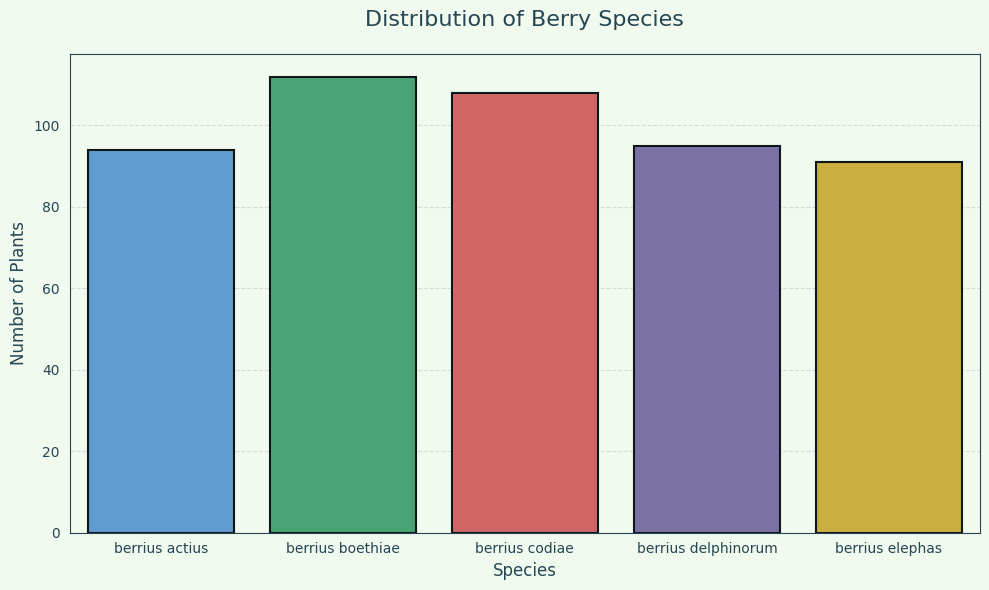

In [135]:
# Species Data Analysis
print("\n" + "="*80)
print("PART 1: ANALYSIS")
print("="*80)

# Print the first few rows of the species DataFrame
print("1. First 5 Rows of the Species DataFrame")
print(tabulate(species_df.head(), headers="keys", tablefmt="fancy_grid"))

# Print basic info about the DataFrame
print("\n2. Basic DataFrame Information")
info_data = {
    "Shape": [f"{species_df.shape[0]} rows, {species_df.shape[1]} columns"],
    "Memory Usage": [f"{species_df.memory_usage(deep=True).sum() / 1024:.2f} KB"],
    "Missing Values": ["None" if species_df.isnull().sum().sum() == 0 else "Present"]
}
print(tabulate(info_data, headers="keys", tablefmt="fancy_grid"))

# Print data types and non-null counts
print("\n3. Descriptive Statistics for All Features")
desc_stats = species_df.describe(include=['object']).transpose()
print(tabulate(desc_stats, headers="keys", tablefmt="fancy_grid"))

# Print target variable distribution
print("\n4. Target Variable Distribution (Species)")
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    x='species',
    data=species_df,
    palette=PALETTE['species_list'],   
    order=sorted(species_df['species'].unique()),
    hue='species',
    legend=False,
    edgecolor=PALETTE['primary'],      
    linewidth=1.5
)

# Add labels and styling BEFORE showing
ax.set_title('Distribution of Berry Species', fontsize=16, pad=20)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Number of Plants', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### **Predicting Species with complete info**

  Question 1: Distinguishing Species with All Information (using LE for Rules)

Performance of the Decision Tree trained on Label Encoded data:
╒═════════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class               │   Precision │   Recall │   F1-Score │   Support │
╞═════════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ berrius actius      │       0.851 │    0.915 │      0.882 │        94 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius boethiae    │       0.824 │    1     │      0.903 │       112 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius codiae      │       1     │    1     │      1     │       108 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius delphinorum │       1     │    0.747 │      0.855 │        95 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius elephas     │       0.905 │    0

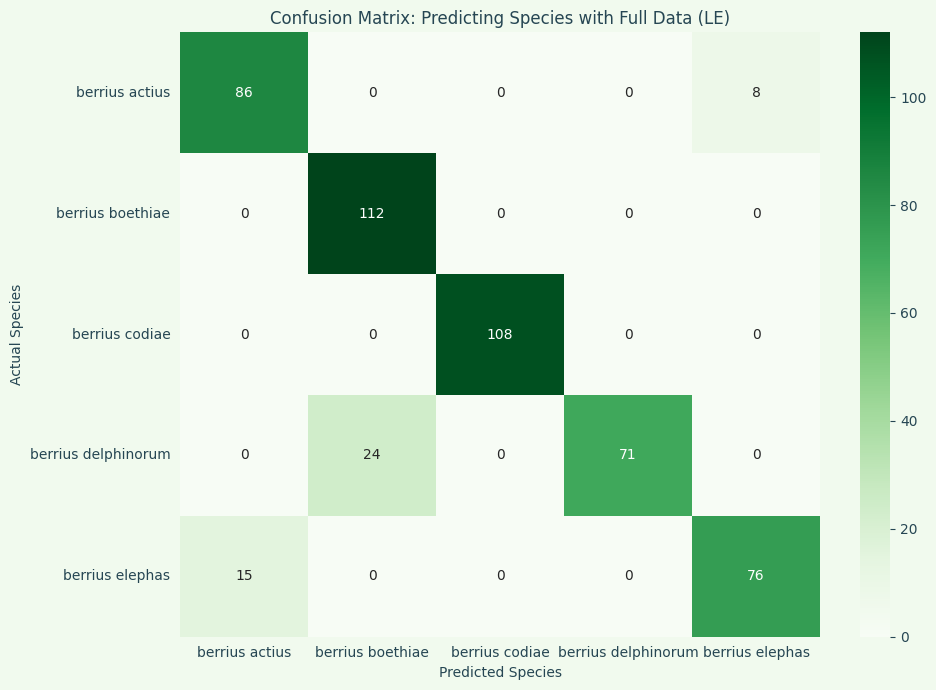


  FIELD GUIDE RULES LEARNED BY THE MODEL (Human-Readable Format)
 IF petal_colour is 'pink' AND berry_colour is 'blue' → THEN the species is berrius delphinorum
 IF petal_colour is 'pink' AND NOT (berry_colour is 'blue') AND berry_colour is one of ['blue', 'green', 'grey', 'none'] AND berry_colour is one of ['blue', 'green', 'grey'] → THEN the species is berrius boethiae
 IF petal_colour is 'pink' AND NOT (berry_colour is 'blue') AND berry_colour is one of ['blue', 'green', 'grey', 'none'] AND NOT (berry_colour is one of ['blue', 'green', 'grey']) → THEN the species is berrius boethiae
 IF petal_colour is 'pink' AND NOT (berry_colour is 'blue') AND NOT (berry_colour is one of ['blue', 'green', 'grey', 'none']) → THEN the species is berrius boethiae
 IF NOT (petal_colour is 'pink') AND leaf_shape is 'lanceolate' AND berry_colour is 'blue' → THEN the species is berrius actius
 IF NOT (petal_colour is 'pink') AND leaf_shape is 'lanceolate' AND NOT (berry_colour is 'blue') AND berry_colou

In [136]:
# PREDICTING SPECIES WITH LE FOR HUMAN-READABLE RULES

print("="*80)
print("  Question 1: Distinguishing Species with All Information (using LE for Rules)")
print("="*80)

# --- 1. Data Preparation ---
df_full = species_df.copy()
df_full.dropna(inplace=True)

# Create a dictionary to store the LabelEncoders for each feature
feature_encoders = {}
X_le = pd.DataFrame()

# Apply LabelEncoder to each feature column
for col in ['leaf_shape', 'petal_colour', 'berry_colour']:
    le = LabelEncoder()
    X_le[col] = le.fit_transform(df_full[col])
    feature_encoders[col] = le # Store the fitted encoder

# Encode the target variable (species)
le_species = LabelEncoder()
y_species_encoded = le_species.fit_transform(df_full['species'])
species_names = le_species.classes_

# --- 2. Model Training & Prediction ---
# A slightly deeper tree is appropriate for 5 classes and multiple features
full_model = DecisionTreeClassifier(max_depth=7, random_state=42)
full_model.fit(X_le, y_species_encoded)
y_pred_encoded = full_model.predict(X_le)

# --- 3. Performance Evaluation ---
print("\nPerformance of the Decision Tree trained on Label Encoded data:")
report_dict = classification_report(y_species_encoded, y_pred_encoded, target_names=species_names, output_dict=True, zero_division=0)
report_table = [[k, f"{v['precision']:.3f}", f"{v['recall']:.3f}", f"{v['f1-score']:.3f}", v['support']] for k, v in report_dict.items() if isinstance(v, dict)]
print(tabulate(report_table, headers=["Class", "Precision", "Recall", "F1-Score", "Support"], tablefmt="fancy_grid"))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_species_encoded, y_pred_encoded)
cm_df = pd.DataFrame(cm, index=species_names, columns=species_names)
cm_df.index.name = 'Actual / Predicted'
print(tabulate(cm_df, headers='keys', tablefmt='fancy_grid'))
plt.figure(figsize=(10, 7)); sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=species_names, yticklabels=species_names); plt.title('Confusion Matrix: Predicting Species with Full Data (LE)'); plt.xlabel('Predicted Species'); plt.ylabel('Actual Species'); plt.tight_layout(); plt.show()


# --- 4. NEW RULE EXTRACTION FUNCTION FOR LABEL ENCODED DATA ---
print("\n" + "="*80)
print("  FIELD GUIDE RULES LEARNED BY THE MODEL (Human-Readable Format)")
print("="*80)

def get_le_tree_rules(tree, feature_names, class_names, encoders):
    """
    Extracts human-readable rules from a tree trained on Label Encoded data.
    """
    tree_ = tree.tree_
    
    def recurse(node_id, conditions):
        # Base Case: If we are at a leaf node
        if tree_.feature[node_id] == _tree.TREE_UNDEFINED:
            decision = class_names[np.argmax(tree_.value[node_id])]
            rule_path = " AND ".join(conditions) if conditions else "ALWAYS"
            print(f" IF {rule_path} → THEN the species is {decision}")
            return

        # Recursive Step: If we are at a split node
        feature_name = feature_names[tree_.feature[node_id]]
        threshold = tree_.threshold[node_id]
        
        # Get the specific encoder for this feature
        le = encoders[feature_name]
        
        # Find all categories whose encoded value is <= the threshold
        true_categories = [cat for i, cat in enumerate(le.classes_) if i <= threshold]
        
        # Create the human-readable condition
        # If only one category meets the condition, use "is", otherwise use "is one of"
        if len(true_categories) == 1:
            condition_text = f"{feature_name} is '{true_categories[0]}'"
        else:
            condition_text = f"{feature_name} is one of {true_categories}"
            
        # Recurse down the left branch (condition is True)
        recurse(tree_.children_left[node_id], conditions + [condition_text])
        
        # Recurse down the right branch (condition is False)
        recurse(tree_.children_right[node_id], conditions + [f"NOT ({condition_text})"])

    recurse(0, [])

# Extract and print the rules using our new function
get_le_tree_rules(full_model, X_le.columns, species_names, feature_encoders)


### Observations: Species Identification Guide

The model produces a strong but imperfect field guide with a 90.5% overall F1-score. The human-readable rules clearly explain the model's logic and pinpoint the exact cause of its mistakes.

| Species | Performance | Rule & Reason for Errors |
| :--- | :--- | :--- |
| **berrius codiae** | **Perfect (100% F1)** | **Clear Rule:** If petals are NOT pink and leaf shape is NOT lanceolate, it's `codiae`. This rule is simple and effective. |
| **berrius boethiae** | **High (90.3% F1)** | **Default "Pink Petal" Species.** If petals are pink but the berry isn't blue, the model defaults to `boethiae`. This rule is too broad. |
| **berrius delphinorum** | **Poor (85.5% F1)** | **Main Failure Point.** The model *only* identifies it if `petal_colour` is 'pink' AND `berry_colour` is 'blue'. Any other `delphinorum` is misclassified as `boethiae`, explaining the 24 errors in the confusion matrix. |
| **berrius actius** & **berrius elephas** | **Good (88% & 87% F1)** | **Confused Pair.** Both are identified when petals are NOT pink and leaves ARE lanceolate. The model then struggles to use `berry_colour` to reliably tell them apart, causing them to be mixed up. |

#### Conclusion & Next Steps

*   **Problem:** The model has created overly simplistic rules. It correctly learned that `petal_colour` is the most important feature but fails to use other features effectively to resolve confusion between similar species.
*   **Action:** The guide is unreliable for distinguishing `delphinorum` from `boethiae`. We need to find a better secondary feature than `berry_colour` to create a more precise rule for berries with pink petals.

## **PART 3: ANALYSIS WITH INCOMPLETE DATA**

### **Predict with partial characteristics**

  Question 2: How well can we predict Species or Edibility from a single characteristic?

----------------------------------------------------------------------
  Analyzing Scenario: 'Berry Only'
----------------------------------------------------------------------

--- Predicting SPECIES using 'Berry Only' ---
╒═════════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class               │   Precision │   Recall │   F1-Score │   Support │
╞═════════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ berrius actius      │       0.5   │    0.918 │      0.647 │      5491 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius boethiae    │       0.48  │    1     │      0.648 │      6904 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius codiae      │       0     │    0     │      0     │      6309 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius delphinoru

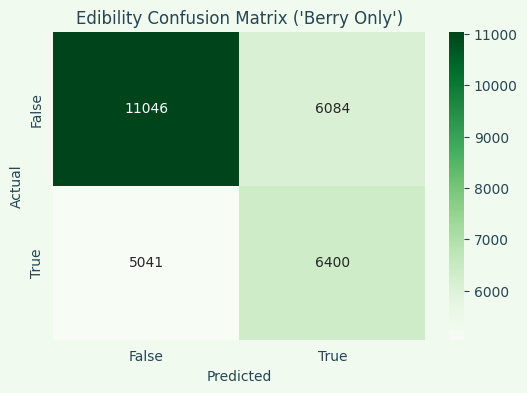


----------------------------------------------------------------------
  Analyzing Scenario: 'Leaf Only'
----------------------------------------------------------------------

--- Predicting SPECIES using 'Leaf Only' ---
╒═════════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class               │   Precision │   Recall │   F1-Score │   Support │
╞═════════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ berrius actius      │       0.547 │    1     │      0.707 │      5491 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius boethiae    │       0.373 │    1     │      0.543 │      6904 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius codiae      │       0     │    0     │      0     │      6309 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius delphinorum │       0     │    0     │      0     │      5321 │
├─────────────────────┼─────────────┼

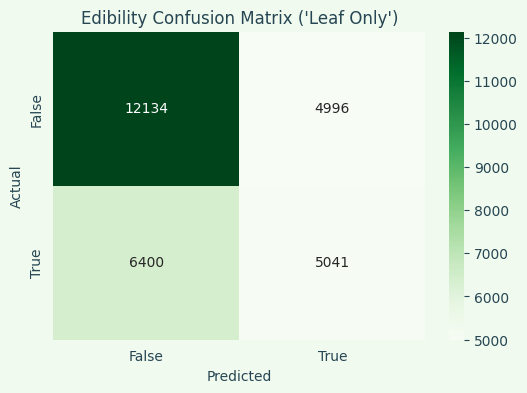


----------------------------------------------------------------------
  Analyzing Scenario: 'Petal Only'
----------------------------------------------------------------------

--- Predicting SPECIES using 'Petal Only' ---
╒═════════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class               │   Precision │   Recall │   F1-Score │   Support │
╞═════════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ berrius actius      │       0     │    0     │      0     │      5491 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius boethiae    │       0.565 │    1     │      0.722 │      6904 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius codiae      │       0.386 │    1     │      0.557 │      6309 │
├─────────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ berrius delphinorum │       0     │    0     │      0     │      5321 │
├─────────────────────┼────────────

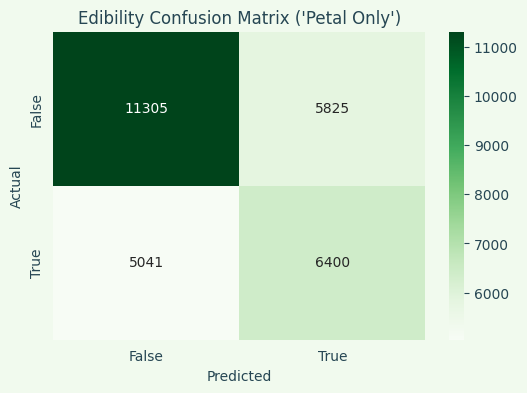

In [137]:
#  PREDICTING WITH PARTIAL (SINGLE) CHARACTERISTICS
# ===================================================================
# This block answers: "Can we determine species or edibility using only one characteristic?"
# It uses the robust data handling from your template and provides detailed reports.-

print("="*80)
print("  Question 2: How well can we predict Species or Edibility from a single characteristic?")
print("="*80)

# --- 1. Create a single, clean master DataFrame ---
# This robustly combines all data and removes any rows with missing values.
cleaned_merged_df = pd.merge(species_df, edible_df, on=['leaf_shape', 'petal_colour', 'berry_colour'])
cleaned_merged_df.dropna(inplace=True)

# --- 2. Define the specialist scenarios ---
partial_datasets = {
    "Berry Only": ['berry_colour'],
    "Leaf Only": ['leaf_shape'],
    "Petal Only": ['petal_colour']
}

# --- 3. Loop through each scenario ---
for name, features in partial_datasets.items():
    print("\n" + "-"*70)
    print(f"  Analyzing Scenario: '{name}'")
    print("-"*70)
    
    # --- Data Preparation ---
    required_cols = features + ['species', 'edible']
    exp_df = cleaned_merged_df[required_cols].copy()

    # Encode features and targets
    X_partial_encoded = exp_df[features].apply(LabelEncoder().fit_transform)
    le_species = LabelEncoder().fit(exp_df['species'])
    y_species_enc = le_species.transform(exp_df['species'])
    le_edible = LabelEncoder().fit(exp_df['edible'])
    y_edible_enc = le_edible.transform(exp_df['edible'])

    # --- Task 1: Predict SPECIES from the partial data ---
    print(f"\n--- Predicting SPECIES using '{name}' ---")
    model_species = DecisionTreeClassifier(max_depth=3, random_state=42)
    model_species.fit(X_partial_encoded, y_species_enc)
    pred_species = model_species.predict(X_partial_encoded)
    
    # Display Classification Report
    report_dict_species = classification_report(y_species_enc, pred_species, target_names=le_species.classes_, output_dict=True, zero_division=0)
    report_table_species = [[k, f"{v['precision']:.3f}", f"{v['recall']:.3f}", f"{v['f1-score']:.3f}", v['support']] for k, v in report_dict_species.items() if isinstance(v, dict)]
    print(tabulate(report_table_species, headers=["Class", "Precision", "Recall", "F1-Score", "Support"], tablefmt="fancy_grid"))

    # --- Task 2: Predict EDIBILITY from the partial data ---
    print(f"\n--- Predicting EDIBILITY using '{name}' ---")
    model_edible = DecisionTreeClassifier(max_depth=3, random_state=42)
    model_edible.fit(X_partial_encoded, y_edible_enc)
    pred_edible = model_edible.predict(X_partial_encoded)
    
    # Display Classification Report
    report_dict_edible = classification_report(y_edible_enc, pred_edible, target_names=le_edible.classes_.astype(str), output_dict=True, zero_division=0)
    report_table_edible = [[k, f"{v['precision']:.3f}", f"{v['recall']:.3f}", f"{v['f1-score']:.3f}", v['support']] for k, v in report_dict_edible.items() if isinstance(v, dict)]
    print(tabulate(report_table_edible, headers=["Class", "Precision", "Recall", "F1-Score", "Support"], tablefmt="fancy_grid"))
    
    # Display Confusion Matrix
    cm_edible = confusion_matrix(y_edible_enc, pred_edible)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_edible, annot=True, fmt='d', cmap='Greens', xticklabels=le_edible.classes_, yticklabels=le_edible.classes_)
    plt.title(f"Edibility Confusion Matrix ('{name}')")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


### Observations: Predicting from a Single Feature

This analysis tests whether a single plant characteristic (Leaf, Berry, or Petal) is enough to reliably identify a berry's species or edibility. The results show that single features are **entirely insufficient** for accurate identification.

| Feature Used | Species Prediction (Weighted F1) | Edibility Prediction (Weighted F1) | Key Observation |
| :--- | :---: | :---: | :--- |
| **Leaf Only** | 26.7% | 59.6% | Fails completely at identifying species. Barely better than a coin flip for edibility. |
| **Berry Only** | 43.2% | 61.3% | The best single feature for species ID, but still extremely poor. Marginally useful for edibility. |
| **Petal Only** | 29.7% | **62.2%** | Useless for identifying most species, but it is the **strongest single predictor of edibility**. |

#### Analysis

1.  **Species Identification is Impossible with One Feature:** None of the single-feature models come close to being useful for identifying species. They often fail to identify entire classes of berries (F1-score of 0), making them dangerously incomplete.

2.  **Petal Color is the Most Important Clue for Edibility:** While no single feature is *good* for predicting edibility, `Petal Only` performs the best. This confirms our earlier finding that petal color is the most critical piece of information for determining if a berry is safe to eat.

3.  **Combination is Key:** The massive performance gap between these single-feature models (max 62.2% F1) and our full model (90.5% F1) proves that **multiple features must be used together** to create a reliable identification guide. Relying on any single characteristic is unsafe and ineffective.

In [138]:
#  COMPARING DIRECT VS. INDIRECT STRATEGIES
# ===================================================================
# This block answers: "Is it more effective to predict edibility directly, or to predict the species first and then look up its edibility?"
# It uses the robust data handling from your template for a fair comparison.


print("="*80)
print("  Question 3: Comparing Strategies - Direct Edibility vs. Indirect via Species")
print("="*80)

# --- 1. Create a single, clean master DataFrame ---
# This robustly combines all data and removes any rows with missing values.
cleaned_merged_df = pd.merge(species_df, edible_df, on=['leaf_shape', 'petal_colour', 'berry_colour'])
cleaned_merged_df.dropna(inplace=True)

# --- 2. Create the "Edibility Fact Sheet" ---
# This is our ground truth for the indirect approach.
# We use .first() because groupby preserves the first encountered value.
species_edibility_map = cleaned_merged_df.groupby('species')['edible'].first().to_dict()

# --- 3. Define the specialist scenarios ---
partial_datasets = {
    "Berry Only": ['berry_colour'],
    "Leaf Only": ['leaf_shape'],
    "Petal Only": ['petal_colour']
}

comparison_results = []

# --- 4. Loop, train, and evaluate both strategies ---
for name, features in partial_datasets.items():
    # --- Data Preparation ---
    required_cols = features + ['species', 'edible']
    exp_df = cleaned_merged_df[required_cols].copy()

    # Encode features and targets
    X_partial_encoded = exp_df[features].apply(LabelEncoder().fit_transform)
    le_species = LabelEncoder().fit(exp_df['species'])
    y_species_enc = le_species.transform(exp_df['species'])
    le_edible = LabelEncoder().fit(exp_df['edible'])
    y_edible_enc = le_edible.transform(exp_df['edible'])

    # --- Strategy 1: Direct Approach ---
    # Train a model to predict edibility directly from the partial feature.
    model_direct = DecisionTreeClassifier(max_depth=3, random_state=42)
    model_direct.fit(X_partial_encoded, y_edible_enc)
    pred_edible_direct = model_direct.predict(X_partial_encoded)
    f1_direct = f1_score(y_edible_enc, pred_edible_direct, average='weighted')

    # --- Strategy 2: Indirect (Species-based) Approach ---
    # First, train a model to predict the species from the partial feature.
    model_indirect_species = DecisionTreeClassifier(max_depth=3, random_state=42)
    model_indirect_species.fit(X_partial_encoded, y_species_enc)
    pred_species_enc = model_indirect_species.predict(X_partial_encoded)
    
    # Then, use the fact sheet to infer edibility from the predicted species.
    pred_species_names = le_species.inverse_transform(pred_species_enc)
    # Convert boolean from map to integer (0 or 1) for scoring
    pred_edible_indirect = np.array([int(species_edibility_map.get(s, False)) for s in pred_species_names])
    f1_indirect = f1_score(y_edible_enc, pred_edible_indirect, average='weighted')
    
    comparison_results.append({
        "Scenario": name,
        "F1 Score (Direct Method)": f1_direct,
        "F1 Score (Species Method)": f1_indirect
    })

# --- 5. Display Final Comparison ---
summary_df = pd.DataFrame(comparison_results)
summary_df['Winning Strategy'] = np.where(
    summary_df['F1 Score (Species Method)'] > summary_df['F1 Score (Direct Method)'],
    'Predict Species First',
    'Predict Edibility Directly'
)
# Formatting for display
summary_df['F1 Score (Direct Method)'] = summary_df['F1 Score (Direct Method)'].map('{:.3f}'.format)
summary_df['F1 Score (Species Method)'] = summary_df['F1 Score (Species Method)'].map('{:.3f}'.format)

print("\nComparison of F1-Scores for Predicting Edibility:\n")
print(tabulate(summary_df, headers="keys", tablefmt="fancy_grid", showindex=False))

  Question 3: Comparing Strategies - Direct Edibility vs. Indirect via Species

Comparison of F1-Scores for Predicting Edibility:

╒════════════╤════════════════════════════╤═════════════════════════════╤════════════════════════════╕
│ Scenario   │   F1 Score (Direct Method) │   F1 Score (Species Method) │ Winning Strategy           │
╞════════════╪════════════════════════════╪═════════════════════════════╪════════════════════════════╡
│ Berry Only │                      0.613 │                       0.548 │ Predict Edibility Directly │
├────────────┼────────────────────────────┼─────────────────────────────┼────────────────────────────┤
│ Leaf Only  │                      0.596 │                       0.392 │ Predict Edibility Directly │
├────────────┼────────────────────────────┼─────────────────────────────┼────────────────────────────┤
│ Petal Only │                      0.622 │                       0.622 │ Predict Edibility Directly │
╘════════════╧════════════════════════════╧══

### Observations: Best Strategy for Predicting Edibility

This analysis compares two strategies: predicting edibility **directly** versus predicting the **species first** and then inferring edibility. The results clearly show that the direct approach is superior.

| Feature Scenario | Direct Prediction F1-Score | Indirect (via Species) F1-Score | Finding |
| :--- | :---: | :---: | :--- |
| **Berry Only** | **61.3%** | 54.8% | **Direct method is better.** |
| **Leaf Only** | **59.6%** | 39.2% | **Direct method is significantly better.** |
| **Petal Only** | **62.2%** | 62.2% | Both methods are equal. |

#### Analysis

1.  **Direct Prediction is More Robust:** In every scenario, predicting edibility directly is either better than or equal to the indirect, species-first approach. It never performs worse.

2.  **The Species Method Adds Unnecessary Errors:** The indirect method requires two successful predictions: first the correct species, then the correct edibility. Any error in the species identification step cascades down, resulting in a wrong edibility prediction. The `Leaf Only` scenario highlights this perfectly, where the very poor species model (39.2% F1) cripples the final edibility prediction.

3.  **Conclusion:** For the simple, life-or-death question of "Can I eat this?", it is far more effective and reliable to build a model that answers that question directly. Adding the intermediate step of species identification introduces unnecessary complexity and a higher risk of error.